# Salary Hike Prediction using Linear Regression

## Objective
Predict salary hike based on years of experience.

## Business Use Case
- Compensation planning
- Fair salary benchmarking
- HR decision support

In [2]:
###import libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
##load dataset
file = "C:/Users/Admin/Documents/ASSIGNMENTS/Salary_Data.csv"
df = pd.read_csv(file)
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [8]:
df.shape

(30, 2)

In [9]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [10]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

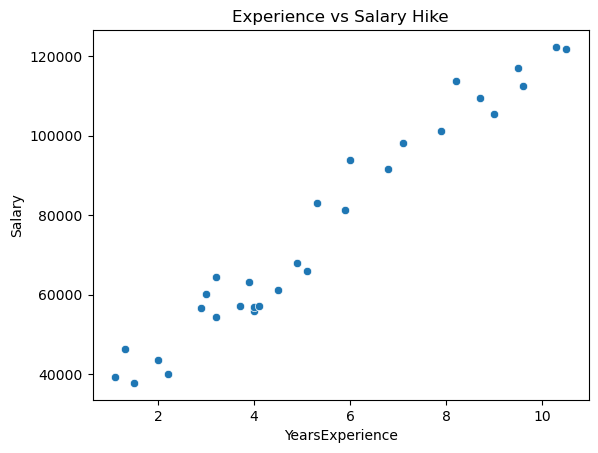

In [12]:
##visualize relationship
sns.scatterplot(x='YearsExperience', y='Salary', data=df)
plt.title("Experience vs Salary Hike")
plt.show()

## EDA Observation

- There is a strong positive linear relationship between Years of Experience and Salary.
- As experience increases, salary also increases.
- The data points are closely aligned, indicating a good fit for a linear regression model.

In [13]:
###split X and y
X = df[['YearsExperience']] 
y = df['Salary']

###training Data
model = LinearRegression()
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
##prediction
y_pred = model.predict(X)
y_pred

array([ 36187.15875227,  38077.15121656,  39967.14368085,  44692.12484158,
        46582.11730587,  53197.09093089,  54142.08716303,  56032.07962732,
        56032.07962732,  60757.06078805,  62647.05325234,  63592.04948449,
        63592.04948449,  64537.04571663,  68317.03064522,  72097.0155738 ,
        73987.00803809,  75877.00050238,  81546.97789525,  82491.9741274 ,
        90051.94398456,  92886.932681  , 100446.90253816, 103281.8912346 ,
       108006.87239533, 110841.86109176, 115566.84225249, 116511.83848464,
       123126.81210966, 125016.80457395])

In [15]:
###comparing actual and predicted data
df = pd.DataFrame({'Actual': y, 'Predicted': y_pred})
df

,Actual,Predicted
0,39343.0,36187.158752
1,46205.0,38077.151217
2,37731.0,39967.143681
3,43525.0,44692.124842
4,39891.0,46582.117306
5,56642.0,53197.090931
6,60150.0,54142.087163
7,54445.0,56032.079627
8,64445.0,56032.079627
9,57189.0,60757.060788


In [18]:
##Evaluation
r2 = r2_score(y,y_pred)
print('r2score:',r2)
rmse = np.sqrt(mean_squared_error(y,y_pred))
print('rmse:',rmse)

r2score: 0.9569566641435086
rmse: 5592.043608760662


## Model Evaluation

- The R² score is 0.957, which indicates that 95.7% of the variation in salary is explained by years of experience.
- This shows a very strong relationship between experience and salary.

- The RMSE value is 5592, meaning the model's predictions deviate from actual salary values by approximately 5592 on average.

## Conclusion

- The model performs very well and provides accurate predictions.
- Years of experience is a strong predictor of salary.
- The linear regression model is suitable for this dataset.

In [22]:
##Transformation
##Log Transformation
#transforn X
X_log = np.log(X)

In [23]:
##build model
model_log = LinearRegression()
model_log.fit(X_log,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
##predict and evaluate
pred_log = model_log.predict(X_log)

r2_log = r2_score(y, pred_log)
print(' r2model_log:',r2_log)

 r2model_log: 0.853888882875697


## Transformation Analysis

- Log transformation was applied to improve model performance.
- However, the R² score did not improve significantly.

## Final Conclusion

- The original linear regression model performs better.
- Therefore, no transformation is required for this dataset.

In [26]:
### Create new data
new_data = pd.DataFrame({'YearsExperience': [2, 5, 10]})

In [27]:
pred = model.predict(new_data)
pred

array([ 44692.12484158,  73042.01180594, 120291.82341322])

In [29]:
##combine results
output = new_data.copy()
output['Predicted_Salary'] = pred
output

,YearsExperience,Predicted_Salary
0,2,44692.124842
1,5,73042.011806
2,10,120291.823413


In [30]:
##save output
output.to_csv("C:/Users/Admin/Documents/Problem2_Predictions.csv", index=False)